# 🧠 SmartPeak : Chronotype Study Time Recommender — PBL Modelling Notebook
#### Tema : Rekomendasi Waktu Belajar Optimal Berdasarkan Chronotype Mahasiswa
--------------------------------------
*   Dataset : Study Habits (Nigeria) — 9,924 data
*   Features :
###### *study_hours_weekly, study_location, preferred_study_time, study_method, procrastination_level, uses_study_aids*
*   *Target* : Chronotype: Lion, Bear, Wolf, Dolphn



Instal Library & Import Library

In [2]:
# IMPORT LIBRARY
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("✅ Libraries siap")

✅ Libraries siap


Load Dataset dan Eksplorasi Data Awal

In [3]:
# LOAD DATA & EKSPLORASI AWAL
file_path = "/content/study_habits_sample.csv"
df_raw = pd.read_csv(file_path)

print("=" * 55)
print("INFORMASI UMUM DATASET")
print("=" * 55)
df_raw.info()
print("=" * 55)
print("\nShape data:", df_raw.shape)
print("=" * 55)

print("\n5 Data Teratas:")
display(df_raw.head())

print("\n")
print("=" * 55)
print("\nStatistik Deskriptif:")
display(df_raw.describe(include='all').T)

INFORMASI UMUM DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   habit_id               10000 non-null  object 
 1   student_id             10000 non-null  object 
 2   study_hours_weekly     9816 non-null   float64
 3   study_location         9901 non-null   object 
 4   preferred_study_time   9912 non-null   object 
 5   study_method           9906 non-null   object 
 6   procrastination_level  9801 non-null   float64
 7   organization_level     9807 non-null   float64
 8   uses_study_aids        10000 non-null  bool   
 9   academic_term          9874 non-null   object 
 10  academic_year          9903 non-null   object 
 11  country                9903 non-null   object 
dtypes: bool(1), float64(3), object(8)
memory usage: 869.3+ KB

Shape data: (10000, 12)

5 Data Teratas:


,habit_id,student_id,study_hours_weekly,study_location,preferred_study_time,study_method,procrastination_level,organization_level,uses_study_aids,academic_term,academic_year,country
0,NGA_HAB_00075721,NGA_STU_00037734,5.1,Home,Afternoon,Group Study,4.0,3.0,True,Term 3,2023/2024,Nigeria
1,NGA_HAB_00080184,NGA_STU_00068308,NaN,Home,Evening,Note-taking,3.0,3.0,True,Term 3,2023/2024,Nigeria
2,NGA_HAB_00019864,NGA_STU_00043560,4.3,Home,Variable,Practice Problems,5.0,4.0,True,Term 2,2023/2024,Nigeria
3,NGA_HAB_00076699,NGA_STU_00029039,13.8,Home,Evening,Note-taking,3.0,5.0,True,Term 1,2024/2025,Nigeria
4,NGA_HAB_00092991,NGA_STU_00040175,12.3,Home,Afternoon,Note-taking,3.0,2.0,True,Term 3,2023/2024,Nigeria





Statistik Deskriptif:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
habit_id,10000,10000,NGA_HAB_00023894,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
student_id,10000,9517,NGA_STU_00078002,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
study_hours_weekly,9816.0,NaN,NaN,NaN,8.053535,3.997955,0.4,5.1,7.4,10.3,30.2
study_location,9901,6,Home,3951,NaN,NaN,NaN,NaN,NaN,NaN,NaN
preferred_study_time,9912,5,Evening,2964,NaN,NaN,NaN,NaN,NaN,NaN,NaN
study_method,9906,6,Note-taking,2445,NaN,NaN,NaN,NaN,NaN,NaN,NaN
procrastination_level,9801.0,NaN,NaN,NaN,3.053362,1.110759,1.0,2.0,3.0,4.0,5.0
organization_level,9807.0,NaN,NaN,NaN,3.232691,1.097203,1.0,3.0,3.0,4.0,5.0
uses_study_aids,10000,2,True,6559,NaN,NaN,NaN,NaN,NaN,NaN,NaN
academic_term,9874,3,Term 2,3387,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Seleksi Fitur

In [4]:
# FEATURE SELECTION
SELECTED_FEATURES = [
    'study_hours_weekly',
    'study_location',
    'preferred_study_time',
    'study_method',
    'procrastination_level',
    'uses_study_aids',
    'organization_level'
]

df = df_raw[SELECTED_FEATURES].copy()

print("Fitur yang digunakan:")
print(SELECTED_FEATURES)
print("=" * 140)
print("\nShape setelah seleksi:", df.shape)
df.head(3)

Fitur yang digunakan:
['study_hours_weekly', 'study_location', 'preferred_study_time', 'study_method', 'procrastination_level', 'uses_study_aids', 'organization_level']

Shape setelah seleksi: (10000, 7)


,study_hours_weekly,study_location,preferred_study_time,study_method,procrastination_level,uses_study_aids,organization_level
0,5.1,Home,Afternoon,Group Study,4.0,True,3.0
1,NaN,Home,Evening,Note-taking,3.0,True,3.0
2,4.3,Home,Variable,Practice Problems,5.0,True,4.0


Cleaning Data

In [5]:
# DATA CLEANING
print("=" * 55)
print("SEBELUM CLEANING")
print("=" * 55)

print(f"Jumlah data awal: {len(df)}")
print("\nMissing Values:")
print(df.isnull().sum())

print("\nJumlah duplikat:", df.duplicated().sum())


# ─── PROSES CLEANING ─────────────────────────────

# 1. Hapus duplikat
n_dup = df.duplicated().sum()
df = df.drop_duplicates()

# 2. Hapus data tanpa target
before = len(df)
df = df.dropna(subset=['preferred_study_time'])
removed_target = before - len(df)

# 3. Isi missing values (AMAN, tanpa inplace)
df['study_hours_weekly'] = df['study_hours_weekly'].fillna(df['study_hours_weekly'].median())
df['procrastination_level'] = df['procrastination_level'].fillna(df['procrastination_level'].median())
df['study_location'] = df['study_location'].fillna(df['study_location'].mode()[0])
df['study_method'] = df['study_method'].fillna(df['study_method'].mode()[0])
df['uses_study_aids'] = df['uses_study_aids'].fillna(df['uses_study_aids'].mode()[0])
df['organization_level'] = df['organization_level'].fillna(df['organization_level'].median())


# ─── HASIL CLEANING ─────────────────────────────

print("\n" + "=" * 55)
print("SETELAH CLEANING")
print("=" * 55)

print(f"Jumlah data akhir: {len(df)}")

print("\nMissing Values setelah cleaning:")
print(df.isnull().sum())

print("\nRingkasan:")
print(f"- Duplikat dihapus          : {n_dup}")
print(f"- Data tanpa target dihapus : {removed_target}")
print(f"- Total data berkurang      : {n_dup + removed_target}")

SEBELUM CLEANING
Jumlah data awal: 10000

Missing Values:
study_hours_weekly       184
study_location            99
preferred_study_time      88
study_method              94
procrastination_level    199
uses_study_aids            0
organization_level       193
dtype: int64

Jumlah duplikat: 124

SETELAH CLEANING
Jumlah data akhir: 9788

Missing Values setelah cleaning:
study_hours_weekly       0
study_location           0
preferred_study_time     0
study_method             0
procrastination_level    0
uses_study_aids          0
organization_level       0
dtype: int64

Ringkasan:
- Duplikat dihapus          : 124
- Data tanpa target dihapus : 88
- Total data berkurang      : 212


DETEKSI OUTLIER
Q1: 5.20
Q3: 10.20
IQR: 5.00
Batas bawah: -2.30
Batas atas : 17.70
Jumlah outlier: 240


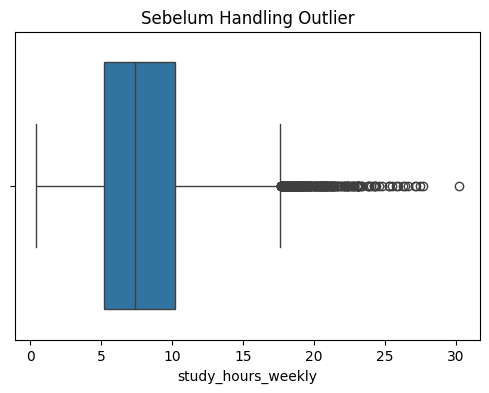

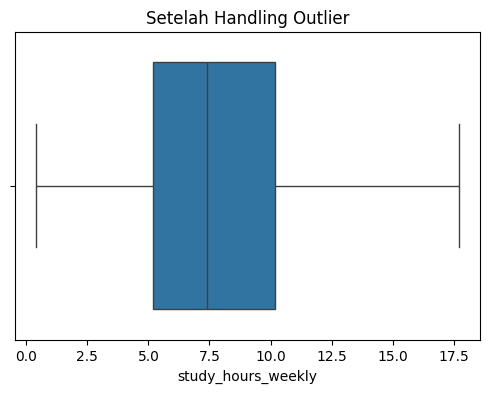

✅ Outlier sudah di-handle dengan metode winsorizing


In [6]:
# OUTLIER HANDLING (IQR)
print("=" * 55)
print("DETEKSI OUTLIER")
print("=" * 55)

Q1 = df['study_hours_weekly'].quantile(0.25)
Q3 = df['study_hours_weekly'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_count = ((df['study_hours_weekly'] < lower_bound) |
                 (df['study_hours_weekly'] > upper_bound)).sum()

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Batas bawah: {lower_bound:.2f}")
print(f"Batas atas : {upper_bound:.2f}")
print(f"Jumlah outlier: {outlier_count}")

# ─── VISUAL SEBELUM ─────────────────────────────
plt.figure(figsize=(6,4))
sns.boxplot(x=df['study_hours_weekly'])
plt.title("Sebelum Handling Outlier")
plt.show()

# ─── HANDLING ─────────────────────────────
df['study_hours_weekly'] = df['study_hours_weekly'].clip(lower_bound, upper_bound)

# ─── VISUAL SESUDAH ─────────────────────────────
plt.figure(figsize=(6,4))
sns.boxplot(x=df['study_hours_weekly'])
plt.title("Setelah Handling Outlier")
plt.show()

print("✅ Outlier sudah di-handle dengan metode winsorizing")

Label

Distribusi Chronotype:


,count
chronotype,
Wolf,4420
Bear,2439
Lion,1933
Dolphin,996


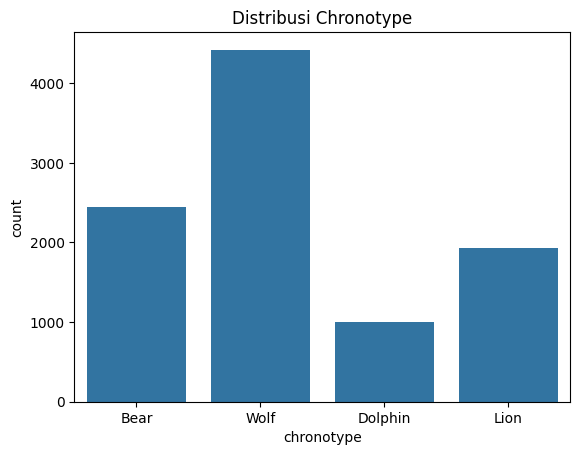

In [7]:
# LABEL ENGINEERING (CHRONOTYPE)
CHRONOTYPE_MAP = {
    'Morning': 'Lion',
    'Afternoon': 'Bear',
    'Evening': 'Wolf',
    'Night': 'Wolf',
    'Variable': 'Dolphin'
}

df['chronotype'] = df['preferred_study_time'].map(CHRONOTYPE_MAP)

print("Distribusi Chronotype:")
display(df['chronotype'].value_counts())

# Visualisasi
sns.countplot(x='chronotype', data=df)
plt.title("Distribusi Chronotype")
plt.show()

BINNING

In [8]:
# BINNING RULE-BASED
df['hours_bin'] = pd.cut(df['study_hours_weekly'],
                         bins=[0,5,10,25],
                         labels=['Low','Medium','High'])

df['proc_bin'] = pd.cut(df['procrastination_level'],
                        bins=[0,2,3,5],
                        labels=['Low','Medium','High'])

print("📊 Distribusi hours_bin:")
display(df['hours_bin'].value_counts())

print("📊 Distribusi proc_bin:")
display(df['proc_bin'].value_counts())

📊 Distribusi hours_bin:


,count
hours_bin,
Medium,4928
High,2556
Low,2304


📊 Distribusi proc_bin:


,count
proc_bin,
Medium,3557
High,3357
Low,2874


Data Split

In [9]:
# DATA SPLIT
idx = np.arange(len(df))

train_idx, test_idx = train_test_split(
    idx, test_size=0.2, random_state=42,
    stratify=df['chronotype']
)

df_train = df.iloc[train_idx].reset_index(drop=True)
df_test  = df.iloc[test_idx].reset_index(drop=True)

print("📌 Train size:", len(df_train))
print("📌 Test size :", len(df_test))

print("\nDistribusi Train:")
display(df_train['chronotype'].value_counts())

print("\nDistribusi Test:")
display(df_test['chronotype'].value_counts())

📌 Train size: 7830
📌 Test size : 1958

Distribusi Train:


,count
chronotype,
Wolf,3536
Bear,1951
Lion,1546
Dolphin,797



Distribusi Test:


,count
chronotype,
Wolf,884
Bear,488
Lion,387
Dolphin,199


##### Forward Chaining

In [10]:
# FORWARD CHAINING MODEL
def forward_chaining(row):

    if row['hours_bin'] == 'High' and row['proc_bin'] == 'Low':
        return 'Lion'

    elif row['hours_bin'] == 'Low' and row['proc_bin'] == 'Low':
        return 'Bear'

    elif row['proc_bin'] == 'High':
        return 'Wolf'

    elif row['study_method'] == 'Group Study':
        return 'Bear'

    elif row['proc_bin'] == 'Medium':
        return 'Dolphin'

    return 'Wolf'

Prediksi

In [11]:
# PREDIKSI
preds = df_test.apply(forward_chaining, axis=1)

print("✅ Prediksi selesai")

✅ Prediksi selesai


Evaluasi Model

In [15]:
# EVALUASI MODEL
y_true = df_test['chronotype']

acc = accuracy_score(y_true, preds)

print("Akurasi:")
print(f"   {acc:.4f} ({acc*100:.2f}%)")

print("\nClassification Report:")
print(classification_report(y_true, preds))


# TABEL HASIL PREDIKSI

hasil = df_test.copy()
hasil['Prediksi'] = preds
hasil['Status'] = np.where(hasil['chronotype'] == hasil['Prediksi'], 'Benar', 'Salah')

# Hitung persentase benar & salah
total = len(hasil)
benar = (hasil['Status'] == 'Benar').sum()
salah = (hasil['Status'] == 'Salah').sum()

persen_benar = benar / total * 100
persen_salah = salah / total * 100

print("\nRingkasan Hasil:")
print(f"   Total Data   : {total}")
print(f"   Benar        : {benar} ({persen_benar:.2f}%)")
print(f"   Salah        : {salah} ({persen_salah:.2f}%)")


print("\nContoh Hasil Prediksi:")
display(hasil[['chronotype','Prediksi','Status']].head(10))

Akurasi:
   0.2840 (28.40%)

Classification Report:
              precision    recall  f1-score   support

        Bear       0.26      0.16      0.20       488
     Dolphin       0.09      0.27      0.14       199
        Lion       0.17      0.07      0.10       387
        Wolf       0.44      0.44      0.44       884

    accuracy                           0.28      1958
   macro avg       0.24      0.24      0.22      1958
weighted avg       0.31      0.28      0.29      1958


Ringkasan Hasil:
   Total Data   : 1958
   Benar        : 556 (28.40%)
   Salah        : 1402 (71.60%)

Contoh Hasil Prediksi:


,chronotype,Prediksi,Status
0,Wolf,Dolphin,Salah
1,Lion,Lion,Benar
2,Wolf,Wolf,Benar
3,Bear,Wolf,Salah
4,Lion,Wolf,Salah
5,Bear,Wolf,Salah
6,Wolf,Dolphin,Salah
7,Wolf,Bear,Salah
8,Wolf,Bear,Salah
9,Lion,Bear,Salah


Visualisasi Hasil

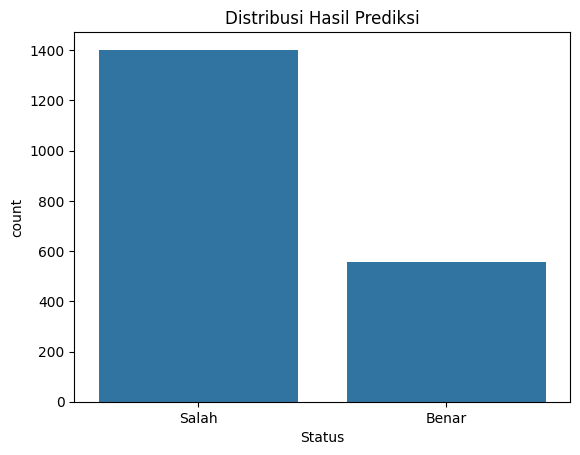

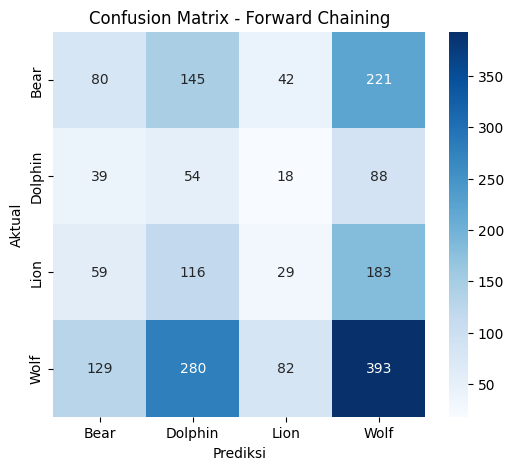

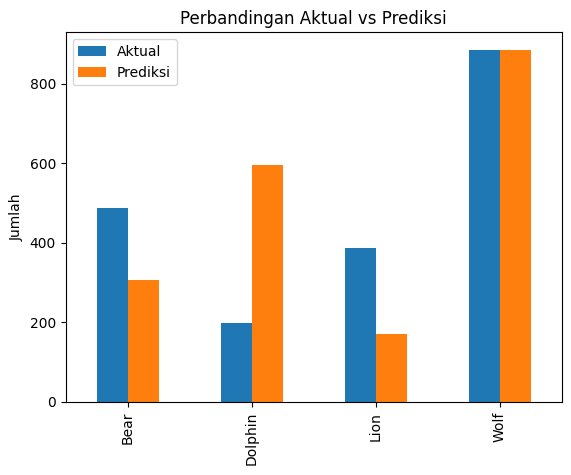

In [14]:
# VISUALISASI HASIL
# 1. Benar vs Salah
sns.countplot(x='Status', data=hasil)
plt.title("Distribusi Hasil Prediksi")
plt.show()

# 2. Confusion Matrix
cm = confusion_matrix(y_true, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_true),
            yticklabels=np.unique(y_true))

plt.title("Confusion Matrix - Forward Chaining")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

# 3. Perbandingan distribusi
pd.DataFrame({
    'Aktual': y_true.value_counts(),
    'Prediksi': pd.Series(preds).value_counts()
}).plot(kind='bar')

plt.title("Perbandingan Aktual vs Prediksi")
plt.ylabel("Jumlah")
plt.show()